In [1]:
# ============================================
# Startup Cell: Mount Drive + Import Config
# ============================================

from google.colab import drive
drive.mount("/content/drive")

import sys
import os

# -------------------------------------------------
# Project base directory (Drive)
# -------------------------------------------------
BASE_DRIVE_DIR = "/content/drive/MyDrive/DIP_Project"

# -------------------------------------------------
# Add src/ to Python path and import config
# -------------------------------------------------
sys.path.append(f"{BASE_DRIVE_DIR}/src")

from project_config import *

# -------------------------------------------------
# Basic environment confirmation
# -------------------------------------------------
print("Drive mounted successfully.")
print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"METADATA_DIR: {METADATA_DIR}")
print(f"PROCESSED_DATA_DIR: {PROCESSED_DATA_DIR}")
print(f"LOCAL_WORK_DIR: {LOCAL_WORK_DIR}")



Mounted at /content/drive
Drive mounted successfully.
BASE_DIR: /content/drive/MyDrive/DIP_Project
DATA_DIR: /content/drive/MyDrive/DIP_Project/data
METADATA_DIR: /content/drive/MyDrive/DIP_Project/data/metadata
PROCESSED_DATA_DIR: /content/drive/MyDrive/DIP_Project/data/preprocessed
LOCAL_WORK_DIR: /content


In [2]:
# ============================================
# Cell 0: Notebook Overview
# ============================================
# Purpose:
#   This notebook verifies and applies gradient-based feature extraction
#   for a selected dataset subset using metadata-driven image selection
#   and preprocessed grayscale images stored on Google Drive.
#
# Inputs:
#   The notebook expects:
#     - a subset-specific metadata CSV file stored in:
#         data/metadata/
#       such as:
#         train_metadata.csv
#         test_metadata.csv
#     - dataset-specific preprocessed image folders stored in:
#         data/preprocessed/<dataset>/images/
#
# Assumptions:
#   - All images have already been preprocessed.
#   - All images are already grayscale.
#   - All images have already been resized to 256 x 256.
#   - This notebook does NOT perform resizing or grayscale conversion.
#   - Input selection is metadata-driven.
#   - Class labels are taken from metadata, not inferred from filenames.
#   - The notebook uses project_config.py as the central source for
#     directory paths, file names, and shared project constants.
#   - This notebook focuses only on gradient-based feature extraction.
#
# What the notebook does:
#   Startup Cell:
#     Mount Google Drive, import project_config.py, and initialize
#     the notebook environment.
#
#   Cell 1:
#     Import required libraries for image loading, numerical processing,
#     feature extraction, and visualization.
#
#   Cell 2:
#     Define the selected subset, input metadata path, preprocessed image
#     root directory, output CSV path, and dataset-folder mapping.
#
#   Cell 3:
#     Verify required inputs exist before processing:
#       - confirm the selected metadata CSV exists
#       - confirm the preprocessed root directory exists
#       - confirm metadata has expected columns
#       - validate subset values
#       - validate source_dataset values
#       - resolve and verify a sample image path
#
#   Cell 4:
#     Load the selected sample image and verify its properties,
#     including:
#       - shape
#       - datatype
#       - intensity range
#
#   Cell 5:
#     Define helper functions for:
#       - entropy computation
#       - Sobel gradient computation
#       - gradient-based feature extraction
#
#   Cell 6:
#     Compute:
#       - horizontal gradient (Gx)
#       - vertical gradient (Gy)
#       - gradient magnitude
#       - gradient orientation
#       - edge mask
#
#   Cell 7:
#     Display intermediate visual results for the sample image:
#       - input image
#       - Gx
#       - Gy
#       - gradient magnitude
#       - gradient orientation
#       - edge mask
#
#   Cell 8:
#     Plot histograms of:
#       - gradient magnitude
#       - gradient orientation
#
#   Cell 9:
#     Compare a small set of real and AI-generated images from the
#     selected subset and print their gradient-based feature values.
#
#   Cell 10:
#     Apply gradient-based feature extraction to all images identified by
#     the selected metadata CSV and save the results to a subset-specific
#     output CSV.
#
#   Cell 11:
#     Reload and verify the saved gradient feature CSV.
#
# Outputs:
#   Primary outputs:
#     - visual validation of gradient extraction behavior
#     - printed gradient-based feature values for selected images
#     - subset-specific gradient feature CSV
#
# Notes:
#   - This notebook supports both exploratory validation and full-subset
#     feature extraction.
#   - Only gradient-based features are extracted in this notebook.
#   - Later notebooks merge gradient, spatial, and frequency-domain
#     features into complete feature vectors for classifier training
#     and evaluation.
#   - This notebook is intended to follow the same structural pattern
#     as the other feature-extraction notebooks for consistency across
#     the project pipeline.
# ============================================

print("Notebook overview loaded.")



Notebook overview loaded.


In [3]:
# ============================================
# Cell 1: Import Required Libraries
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm.notebook import tqdm

from PIL import Image
from scipy.stats import entropy
from scipy.ndimage import sobel

print("Libraries imported successfully.")



Libraries imported successfully.


In [4]:
# ============================================
# Cell 2: Define Subset and Paths
# ============================================

SUBSET_NAME = TRAIN_SUBSET

if SUBSET_NAME == TRAIN_SUBSET:
    INPUT_METADATA_CSV = os.path.join(METADATA_DIR, TRAIN_METADATA_FILENAME)
    OUTPUT_FEATURES_CSV = os.path.join(METADATA_DIR, "train_gradient_features.csv")
elif SUBSET_NAME == TEST_SUBSET:
    INPUT_METADATA_CSV = os.path.join(METADATA_DIR, TEST_METADATA_FILENAME)
    OUTPUT_FEATURES_CSV = os.path.join(METADATA_DIR, "test_gradient_features.csv")
else:
    raise ValueError(f"Unsupported subset: {SUBSET_NAME}")

# Base directory containing dataset-specific preprocessed image folders
PREPROCESSED_ROOT_DIR = PROCESSED_DATA_DIR

# Map metadata source_dataset values to actual folder names in Drive
SOURCE_DATASET_TO_FOLDER = {
    "DiffusionDB": "DiffusionDB",
    "SDXL_Generated_10K": "SDXL_Generated_10K",
    "Midjourney": "Midjourney",
    "ImageNet_1K_256": "ImageNet_1K_256",
    "MS_COCO_2017": "MS_COCO_2017",
    "OpenImages": "OpenImages",
}

SAMPLE_IMAGE_PATH = None
SAMPLE_IMAGE_NAME = None

print(f"Selected subset: {SUBSET_NAME}")
print(f"Input metadata CSV: {INPUT_METADATA_CSV}")
print(f"Preprocessed root directory: {PREPROCESSED_ROOT_DIR}")
print(f"Output feature CSV: {OUTPUT_FEATURES_CSV}")



Selected subset: train
Input metadata CSV: /content/drive/MyDrive/DIP_Project/data/metadata/train_metadata.csv
Preprocessed root directory: /content/drive/MyDrive/DIP_Project/data/preprocessed
Output feature CSV: /content/drive/MyDrive/DIP_Project/data/metadata/train_gradient_features.csv


In [5]:
# ============================================
# Cell 3: Verify Inputs and Select Sample Image
# ============================================

required_metadata_columns = [
    "filename",
    "class_label",
    "source_dataset",
    "subset",
]

print("Validating inputs...")

# --------------------------------------------
# Check metadata CSV
# --------------------------------------------
if not os.path.exists(INPUT_METADATA_CSV):
    raise FileNotFoundError(f"Missing metadata CSV: {INPUT_METADATA_CSV}")

# --------------------------------------------
# Check preprocessed root directory
# --------------------------------------------
if not os.path.isdir(PREPROCESSED_ROOT_DIR):
    raise FileNotFoundError(
        f"Missing preprocessed root directory: {PREPROCESSED_ROOT_DIR}"
    )

# --------------------------------------------
# Load metadata
# --------------------------------------------
df_meta = pd.read_csv(INPUT_METADATA_CSV)

# --------------------------------------------
# Validate required columns
# --------------------------------------------
missing_columns = [
    col for col in required_metadata_columns
    if col not in df_meta.columns
]

if missing_columns:
    raise ValueError(f"Missing required metadata columns: {missing_columns}")

# --------------------------------------------
# Validate subset
# --------------------------------------------
if not all(df_meta["subset"] == SUBSET_NAME):
    raise ValueError(
        f"Metadata contains rows outside subset '{SUBSET_NAME}'"
    )

# --------------------------------------------
# Validate source_dataset values
# --------------------------------------------
unknown_sources = [
    s for s in df_meta["source_dataset"].unique()
    if s not in SOURCE_DATASET_TO_FOLDER
]

if unknown_sources:
    raise ValueError(f"Unknown source_dataset values: {unknown_sources}")

# --------------------------------------------
# Helper: build full image path
# --------------------------------------------
def get_image_path(row):
    return os.path.join(
        PREPROCESSED_ROOT_DIR,
        SOURCE_DATASET_TO_FOLDER[row["source_dataset"]],
        "images",
        row["filename"],
    )

# --------------------------------------------
# Select sample image
# --------------------------------------------
sample_row = df_meta.iloc[0]
SAMPLE_IMAGE_NAME = sample_row["filename"]
SAMPLE_IMAGE_PATH = get_image_path(sample_row)

if not os.path.exists(SAMPLE_IMAGE_PATH):
    raise FileNotFoundError(f"Sample image not found: {SAMPLE_IMAGE_PATH}")

# --------------------------------------------
# Minimal confirmation output
# --------------------------------------------
print(f"Rows: {len(df_meta)}")
display(df_meta.head())



Validating inputs...
Rows: 14400


,filename,source_dataset,class_label,subset
0,rl_imgn_002320.png,ImageNet_1K_256,rl,train
1,rl_coco_001397.png,MS_COCO_2017,rl,train
2,rl_imgn_001958.png,ImageNet_1K_256,rl,train
3,rl_coco_000800.png,MS_COCO_2017,rl,train
4,ai_mj_002892.png,Midjourney,ai,train


Sample image loaded successfully.
Sample image name: rl_imgn_002320.png
Sample image path: /content/drive/MyDrive/DIP_Project/data/preprocessed/ImageNet_1K_256/images/rl_imgn_002320.png
Shape: (256, 256)
Data type: uint8
Min intensity: 0
Max intensity: 255


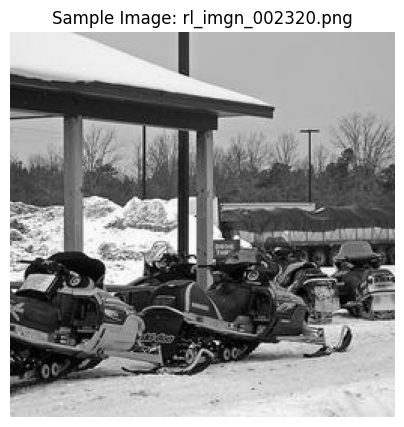

In [6]:
# ============================================
# Cell 4: Load Sample Image and Verify Properties
# ============================================

sample_image = Image.open(SAMPLE_IMAGE_PATH)
sample_array = np.array(sample_image)

print("Sample image loaded successfully.")
print(f"Sample image name: {SAMPLE_IMAGE_NAME}")
print(f"Sample image path: {SAMPLE_IMAGE_PATH}")
print(f"Shape: {sample_array.shape}")
print(f"Data type: {sample_array.dtype}")
print(f"Min intensity: {sample_array.min()}")
print(f"Max intensity: {sample_array.max()}")

plt.figure(figsize=(5, 5))
plt.imshow(sample_array, cmap="gray")
plt.title(f"Sample Image: {SAMPLE_IMAGE_NAME}")
plt.axis("off")
plt.show()



In [7]:
# ============================================
# Cell 5: Gradient and Feature Helper Functions
# ============================================

def safe_entropy_from_hist(hist, eps=1e-12):
    hist = hist.astype(np.float64)
    hist = hist / (hist.sum() + eps)
    hist = np.clip(hist, eps, None)
    return float(entropy(hist, base=2))


def compute_gradients(img):
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)

    mag = np.sqrt(gx ** 2 + gy ** 2)
    ori = np.arctan2(gy, gx)

    return gx, gy, mag, ori


def extract_gradient_features(img):
    gx, gy, mag, ori = compute_gradients(img)

    mean_grad = float(np.mean(mag))
    std_grad = float(np.std(mag))
    max_grad = float(np.max(mag))

    mag_max = max(float(mag.max()), 1e-6)
    mag_hist, _ = np.histogram(mag.ravel(), bins=64, range=(0.0, mag_max))
    grad_entropy = safe_entropy_from_hist(mag_hist)

    edge_threshold = np.mean(mag) + np.std(mag)
    edge_mask = mag > edge_threshold
    edge_density = float(np.mean(edge_mask))

    ori_hist, _ = np.histogram(ori.ravel(), bins=36, range=(-np.pi, np.pi))
    ori_entropy = safe_entropy_from_hist(ori_hist)

    features = {
        "Mean Gradient": mean_grad,
        "Std Gradient": std_grad,
        "Max Gradient": max_grad,
        "Gradient Entropy": grad_entropy,
        "Edge Density": edge_density,
        "Orientation Mean": float(np.mean(ori)),
        "Orientation Std": float(np.std(ori)),
        "Orientation Entropy": ori_entropy,
    }

    return features, gx, gy, mag, ori, edge_mask

print("Gradient helper functions defined.")



Gradient helper functions defined.


In [8]:
# ============================================
# Cell 6: Compute Gradient Components
# ============================================

features, gx, gy, mag, ori, edge_mask = extract_gradient_features(sample_array)

print(f"Gradient components computed for sample image: {SAMPLE_IMAGE_NAME}")
print(f"Gx/Gy/Mag/Ori shape: {gx.shape}")
print(f"Edge mask shape: {edge_mask.shape}")



Gradient components computed for sample image: rl_imgn_002320.png
Gx/Gy/Mag/Ori shape: (256, 256)
Edge mask shape: (256, 256)


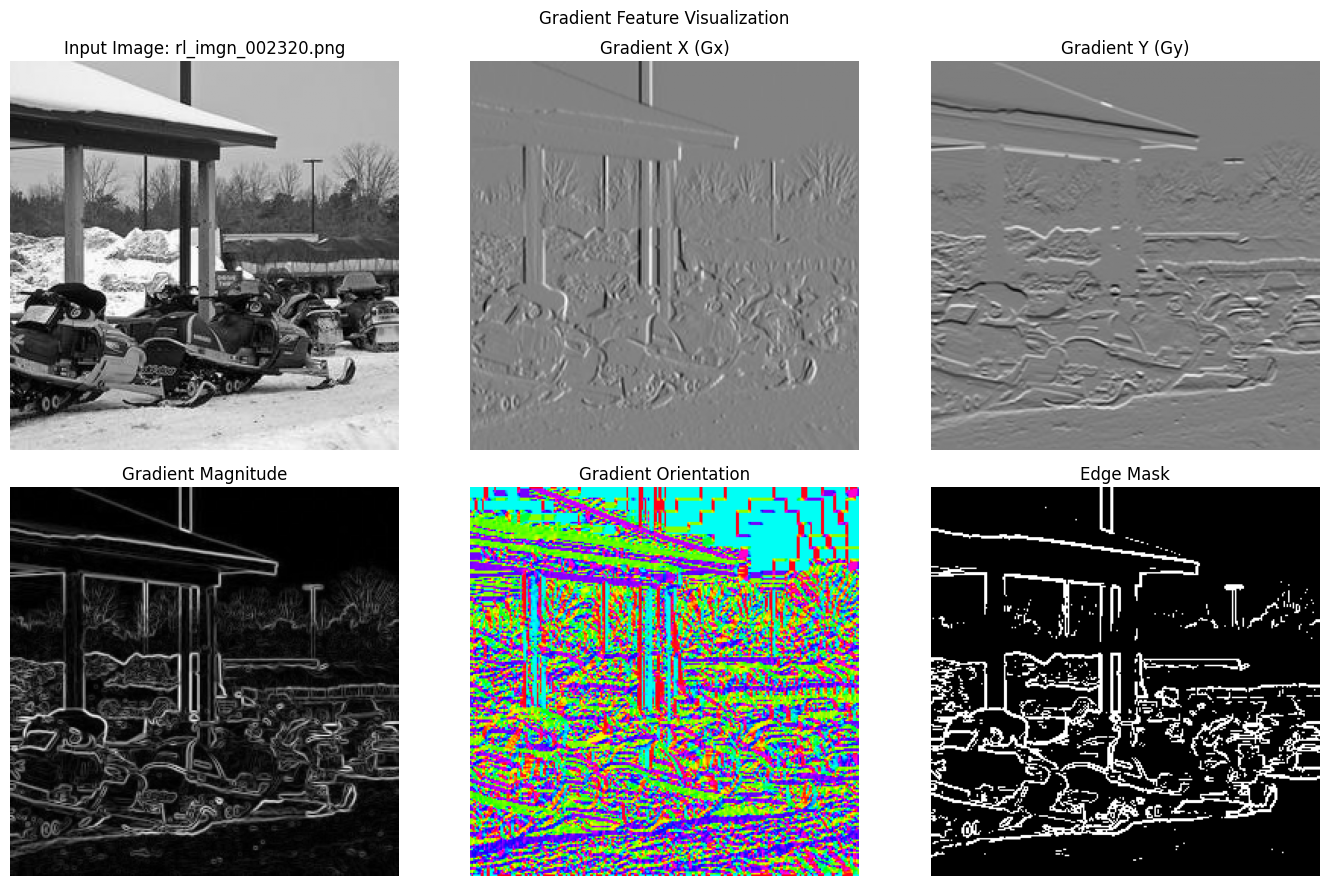

In [9]:
# ============================================
# Cell 7: Display Gradient Visualization Results
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0, 0].imshow(sample_array, cmap="gray")
axes[0, 0].set_title(f"Input Image: {SAMPLE_IMAGE_NAME}")
axes[0, 0].axis("off")

axes[0, 1].imshow(gx, cmap="gray")
axes[0, 1].set_title("Gradient X (Gx)")
axes[0, 1].axis("off")

axes[0, 2].imshow(gy, cmap="gray")
axes[0, 2].set_title("Gradient Y (Gy)")
axes[0, 2].axis("off")

axes[1, 0].imshow(mag, cmap="gray")
axes[1, 0].set_title("Gradient Magnitude")
axes[1, 0].axis("off")

axes[1, 1].imshow(ori, cmap="hsv", vmin=-np.pi, vmax=np.pi)
axes[1, 1].set_title("Gradient Orientation")
axes[1, 1].axis("off")

axes[1, 2].imshow(edge_mask, cmap="gray")
axes[1, 2].set_title("Edge Mask")
axes[1, 2].axis("off")

plt.suptitle("Gradient Feature Visualization", fontsize=12)
plt.tight_layout()
plt.show()



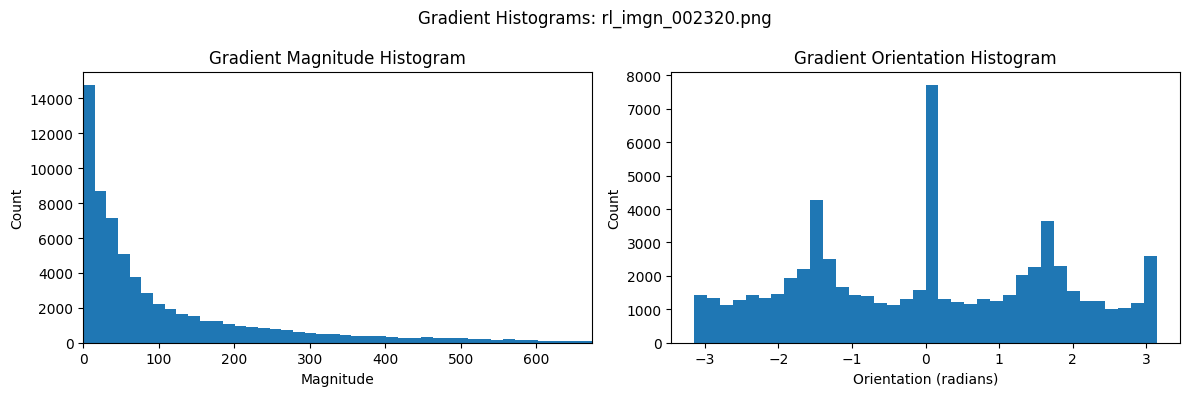

In [10]:
# ============================================
# Cell 8: Plot Gradient Histograms
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mag.ravel(), bins=64)
axes[0].set_xlim(0, np.percentile(mag, 99))
axes[0].set_title("Gradient Magnitude Histogram")
axes[0].set_xlabel("Magnitude")
axes[0].set_ylabel("Count")

axes[1].hist(ori.ravel(), bins=36, range=(-np.pi, np.pi))
axes[1].set_title("Gradient Orientation Histogram")
axes[1].set_xlabel("Orientation (radians)")
axes[1].set_ylabel("Count")

plt.suptitle(f"Gradient Histograms: {SAMPLE_IMAGE_NAME}", fontsize=12)
plt.tight_layout()
plt.show()



Selected images from train subset:
          filename class_label  source_dataset
rl_coco_002716.png          rl    MS_COCO_2017
rl_imgn_001274.png          rl ImageNet_1K_256
  ai_mj_002765.png          ai      Midjourney
  ai_mj_000683.png          ai      Midjourney

Class counts:
class_label
rl    2
ai    2

Total selected: 4

TRAIN | Image 1 of 4
Filename: rl_coco_002716.png
Label: rl | Source: MS_COCO_2017
Mean Gradient            : 87.751930
Std Gradient             : 97.635246
Max Gradient             : 956.353516
Gradient Entropy         : 3.980442
Edge Density             : 0.121765
Orientation Mean         : -0.084192
Orientation Std          : 1.818512
Orientation Entropy      : 5.143306


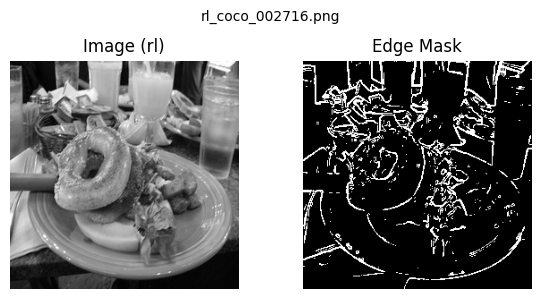


TRAIN | Image 2 of 4
Filename: rl_imgn_001274.png
Label: rl | Source: ImageNet_1K_256
Mean Gradient            : 194.454727
Std Gradient             : 183.724503
Max Gradient             : 980.449890
Gradient Entropy         : 5.084450
Edge Density             : 0.155655
Orientation Mean         : 0.039499
Orientation Std          : 1.759065
Orientation Entropy      : 4.983031


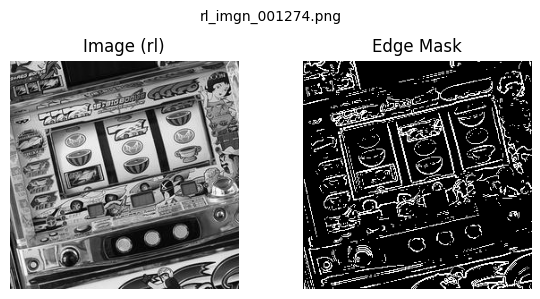


TRAIN | Image 3 of 4
Filename: ai_mj_002765.png
Label: ai | Source: Midjourney
Mean Gradient            : 79.256035
Std Gradient             : 91.508545
Max Gradient             : 897.669189
Gradient Entropy         : 3.905375
Edge Density             : 0.122925
Orientation Mean         : -0.221086
Orientation Std          : 1.768749
Orientation Entropy      : 5.101090


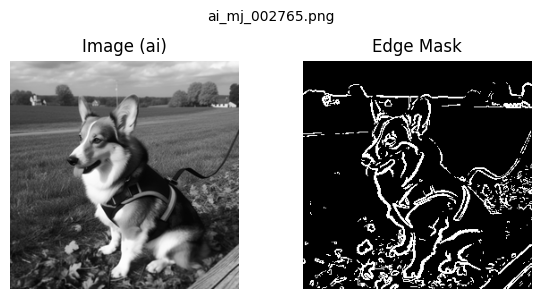


TRAIN | Image 4 of 4
Filename: ai_mj_000683.png
Label: ai | Source: Midjourney
Mean Gradient            : 42.910675
Std Gradient             : 79.659142
Max Gradient             : 980.996460
Gradient Entropy         : 2.648614
Edge Density             : 0.097946
Orientation Mean         : 0.104354
Orientation Std          : 1.563802
Orientation Entropy      : 4.670405


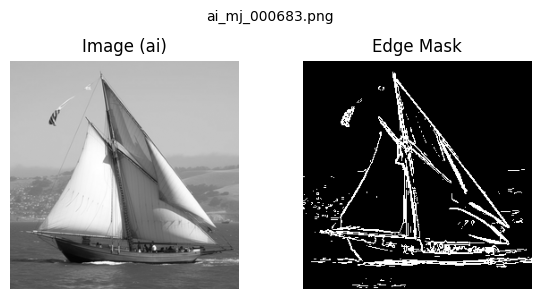

In [11]:
# ============================================
# Cell 9: Compare Real vs AI Images
# ============================================

# Select 2 real and 2 AI images (safe sampling)
df_real = df_meta[df_meta["class_label"] == "rl"].sample(
    n=min(2, len(df_meta[df_meta["class_label"] == "rl"])),
    random_state=42
)

df_ai = df_meta[df_meta["class_label"] == "ai"].sample(
    n=min(2, len(df_meta[df_meta["class_label"] == "ai"])),
    random_state=42
)

sample_df = pd.concat([df_real, df_ai], axis=0).reset_index(drop=True)

print(f"Selected images from {SUBSET_NAME} subset:")
print(sample_df[["filename", "class_label", "source_dataset"]].to_string(index=False))
print("\nClass counts:")
print(sample_df["class_label"].value_counts().to_string())
print(f"\nTotal selected: {len(sample_df)}")

for i, row in sample_df.iterrows():
    fname = row["filename"]
    label = row["class_label"]
    source = row["source_dataset"]

    image_path = get_image_path(row)

    img_sample = np.array(Image.open(image_path))
    features_sample, gx_s, gy_s, mag_s, ori_s, edge_s = extract_gradient_features(img_sample)

    print("\n============================================")
    print(f"{SUBSET_NAME.upper()} | Image {i+1} of {len(sample_df)}")
    print(f"Filename: {fname}")
    print(f"Label: {label} | Source: {source}")

    for k, v in features_sample.items():
        print(f"{k:25s}: {v:.6f}")

    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(img_sample, cmap="gray")
    plt.title(f"Image ({label})")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(edge_s, cmap="gray")
    plt.title("Edge Mask")
    plt.axis("off")

    plt.suptitle(fname, fontsize=10)
    plt.tight_layout()
    plt.show()



In [12]:
# ============================================
# Cell 10: Batch Gradient Feature Extraction
# ============================================

rows = []
skipped = 0

for _, row in tqdm(
    df_meta.iterrows(),
    total=len(df_meta),
    desc=f"{SUBSET_NAME} gradient features"
):
    fname = row["filename"]
    image_path = get_image_path(row)

    try:
        img_batch = np.array(Image.open(image_path))
        features_batch, _, _, _, _, _ = extract_gradient_features(img_batch)

        out_row = row.to_dict()
        out_row.update(features_batch)
        rows.append(out_row)

    except Exception as e:
        skipped += 1
        print(f"Skipping {fname}: {e}")

features_df = pd.DataFrame(rows)
features_df.to_csv(OUTPUT_FEATURES_CSV, index=False)

print(f"Saved: {OUTPUT_FEATURES_CSV}")
print(f"Expected rows: {len(df_meta)}")
print(f"Extracted rows: {len(features_df)}")
print(f"Skipped rows: {skipped}")
print(f"Processed subset: {SUBSET_NAME}")



train gradient features:   0%|          | 0/14400 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/DIP_Project/data/metadata/train_gradient_features.csv
Expected rows: 14400
Extracted rows: 14400
Skipped rows: 0
Processed subset: train


In [14]:
# ============================================
# Cell 11: Verify Saved Gradient Feature CSV
# ============================================

df_check = pd.read_csv(OUTPUT_FEATURES_CSV)

print("Saved gradient feature CSV verified.")
print(f"File: {OUTPUT_FEATURES_CSV}")
print(f"Shape: {df_check.shape}")
print("\nColumns:")
print(df_check.columns.tolist())

print("\nFirst 5 rows:")
display(df_check.head())



Saved gradient feature CSV verified.
File: /content/drive/MyDrive/DIP_Project/data/metadata/train_gradient_features.csv
Shape: (14400, 12)

Columns:
['filename', 'source_dataset', 'class_label', 'subset', 'Mean Gradient', 'Std Gradient', 'Max Gradient', 'Gradient Entropy', 'Edge Density', 'Orientation Mean', 'Orientation Std', 'Orientation Entropy']

First 5 rows:


,filename,source_dataset,class_label,subset,Mean Gradient,Std Gradient,Max Gradient,Gradient Entropy,Edge Density,Orientation Mean,Orientation Std,Orientation Entropy
0,rl_imgn_002320.png,ImageNet_1K_256,rl,train,113.284256,148.626465,988.380493,4.200053,0.133926,0.009213,1.708909,4.952383
1,rl_coco_001397.png,MS_COCO_2017,rl,train,58.244781,91.992287,943.153198,3.224193,0.104218,0.003133,1.812218,5.067689
2,rl_imgn_001958.png,ImageNet_1K_256,rl,train,99.089622,129.458405,955.745789,4.071966,0.119492,-0.031641,1.761121,5.136969
3,rl_coco_000800.png,MS_COCO_2017,rl,train,76.498199,114.998993,924.299744,3.541116,0.123779,0.210707,1.640483,5.021997
4,ai_mj_002892.png,Midjourney,ai,train,67.460518,74.748627,801.519836,3.823527,0.113922,-0.004285,1.853334,5.145963
